# 01 - Analiza skupa podataka

U ovoj svesci upoznajemo skup podataka pre bilo kakvog modelovanja. Gledamo:

1. strukturu satnog i dnevnog fajla i značenje kolona
2. nedostajuće vrednosti i nedostajuće redove
3. raspodelu ciljne promenljive i njen oblik kroz dan
4. uticaj vremenskih uslova i rast sistema između dve godine
5. razliku između satnog i dnevnog nivoa

Nalazi iz ove sveske određuju odluke u svesci 02: koje atribute izbacujemo, kako ih kodiramo i kako delimo podatke.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(7)

# Učitavanje skupa podataka

In [3]:
sat = pd.read_csv("../data/hour.csv")
dan = pd.read_csv("../data/day.csv")

In [4]:
sat.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
sat.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [6]:
sat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
sat.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Skup podataka je preuzet iz UCI repozitorijuma i opisuje sistem javnih bicikala Capital Bikeshare
u Vašingtonu tokom 2011. i 2012. godine.

Satni fajl sadrži: 17379 redova i 17 kolona

Dnevni fajl sadrži 731 red i 16 kolona. Svaki red satnog fajla predstavlja jedan sat,
a svaki red dnevnog fajla jedan dan.

Značenje kolona:

- instant -> redni broj zapisa;
- dteday -> datum;
- season -> godišnje doba (1 zima, 2 proleće, 3 leto, 4 jesen);
- yr -> godina (0 je 2011, 1 je 2012);
- mnth -> mesec;
- hr -> sat u danu, samo u satnom fajlu;
- holiday -> praznik;
- weekday -> dan u nedelji;
- workingday -> 1 ako nije ni vikend ni praznik;
- weathersit -> stanje vremena (1 vedro, 2 oblačno, 3 slaba kiša ili sneg, 4 jaka kiša ili sneg);
- temp, atemp, hum, windspeed -> temperatura, osećaj temperature, vlažnost i vetar, normalizovani na 0 do 1;
- casual -> broj povremenih korisnika;
- registered -> broj registrovanih korisnika;
- cnt -> ukupan broj iznajmljivanja, ciljna promenljiva

Vrednosti ciljne promenljive cnt kreću se od 1 do 977, sa medijanom 142 i srednjom vrednošću 189,
što već ukazuje na raspodelu iskošenu udesno.

Isti pregled radimo i za dnevni fajl.

In [8]:
dan.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [9]:
dan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [10]:
dan.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Dnevni fajl ima 731 red i 16 kolona. Kolone su iste kao u satnom, samo bez atributa hr,
jer je jedan red ceo dan.

Vrednosti ciljne promenljive su ovde reda hiljada, a ne stotina, jer predstavljaju
zbir svih sati u danu. Srednja vrednost je 4504, medijana 4548, a maksimum 8714.

Primetimo da su srednja vrednost i medijana gotovo jednake, za razliku od satnog nivoa
gde su se osetno razlikovale. To znači da je raspodela na dnevnom nivou znatno simetričnija,
što proveravamo u nastavku.

# Analiza skupa podataka

In [11]:
missing = sat.isnull().sum()

missing_percent = (missing / len(sat)) * 100

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_table.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
instant,0,0.0
weathersit,0,0.0
registered,0,0.0
casual,0,0.0
windspeed,0,0.0
hum,0,0.0
atemp,0,0.0
temp,0,0.0
workingday,0,0.0
dteday,0,0.0


U skupu podataka nema nedostajućih vrednosti ni u jednoj koloni. Time otpada ceo korak
popunjavanja ili izbacivanja redova.

Odsustvo praznih polja, međutim, ne znači da ništa ne nedostaje. Provera koja sledi
pokazuje da nedostaju čitavi redovi.

In [12]:
broj_dana = sat["dteday"].nunique()
ocekivano = broj_dana * 24

print("period:", sat["dteday"].min(), "-", sat["dteday"].max())
print("broj dana:", broj_dana)
print("očekivano redova:", ocekivano)
print("stvarno redova:", len(sat))
print("nedostaje redova:", ocekivano - len(sat))

period: 2011-01-01 - 2012-12-31
broj dana: 731
očekivano redova: 17544
stvarno redova: 17379
nedostaje redova: 165


Period obuhvata 731 dan, što bi uz 24 sata dnevno dalo 17544 reda. Skup ih ima 17379,
dakle nedostaje 165 sati.

Ti sati ne postoje kao redovi. U njima nije izdat nijedan bicikl, pa sistem nije ni zabeležio
zapis, umesto da upiše red sa vrednošću nula. Metod isnull() takvu prazninu ne može da otkrije,
jer prazno polje ne postoji, nego ne postoji ceo red.

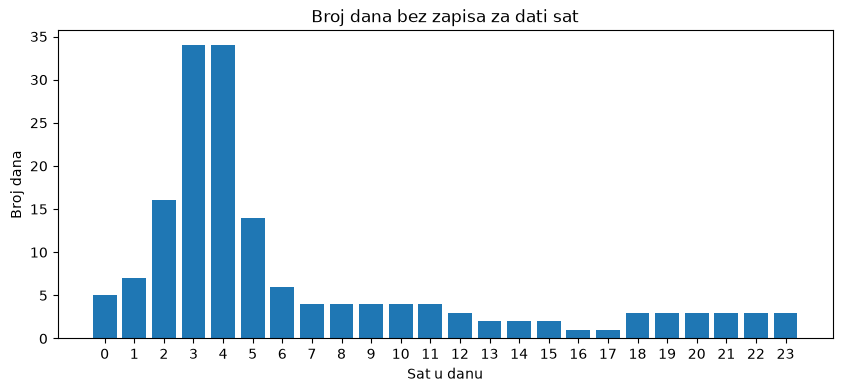

In [13]:
zapisa_po_satu = sat.groupby("hr").size()

plt.figure(figsize=(10,4))
plt.bar(zapisa_po_satu.index, broj_dana - zapisa_po_satu.values)

plt.title("Broj dana bez zapisa za dati sat")
plt.xlabel("Sat u danu")
plt.ylabel("Broj dana")
plt.xticks(range(0,24))

plt.show()

Nedostajući sati su uglavnom noćni: najviše ih je u 3 i 4 ujutru, po 34 dana, a oko 70 odsto svih pada između ponoći i 6h.

Pošto model gradimo tako da broj iznajmljivanja predviđa iz sata i vremenskih uslova, a ne iz prethodnih vrednosti, ove praznine ne moramo popunjavati.

In [14]:
bool((sat["casual"] + sat["registered"] == sat["cnt"]).all())

True

Kolona cnt je tačno zbir kolona casual i registered, u svakom redu bez izuzetka.

Ovo je važno zapaziti pre modelovanja. Ako bismo predviđali cnt a u ulazne atribute
ostavili casual i registered, model bi imao savršenu tačnost i ne bi naučio ništa,
jer bi samo sabirao dva broja koja smo mu dali. Reč je o curenju informacija,
odnosno o situaciji u kojoj u atribute uđe podatak koji u trenutku predviđanja
ne bi bio dostupan.

Ta dva atributa biće izbačena iz ulaza u svesci 02. Istovremeno ih zadržavamo
za analizu, jer razdvajaju dve različite grupe korisnika.

## Analiza ciljne promenljive

In [15]:
print(sat["cnt"].describe())
print()
print("iskošenost:", round(sat["cnt"].skew(), 3))

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

iskošenost: 1.277


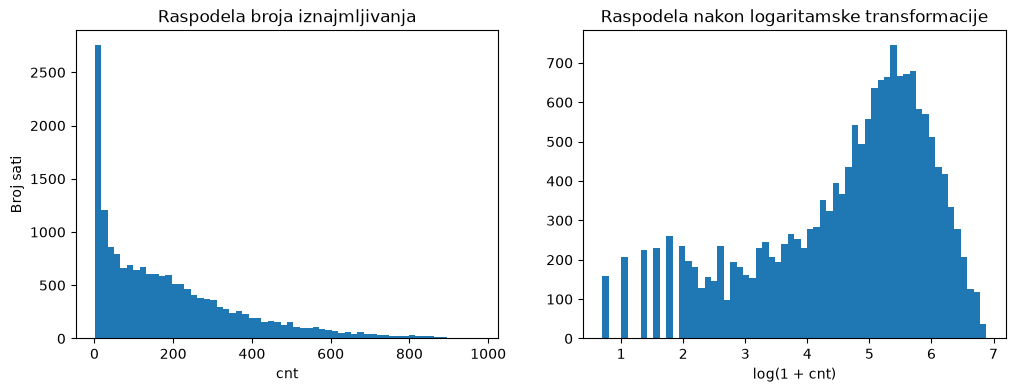

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].hist(sat["cnt"], bins=60)
ax[0].set_title("Raspodela broja iznajmljivanja")
ax[0].set_xlabel("cnt")
ax[0].set_ylabel("Broj sati")

ax[1].hist(np.log1p(sat["cnt"]), bins=60)
ax[1].set_title("Raspodela nakon logaritamske transformacije")
ax[1].set_xlabel("log(1 + cnt)")

plt.show()

Raspodela ciljne promenljive je iskošena udesno, sa koeficijentom iskošenosti 1.28. Postoji mnogo sati sa malim brojem iznajmljivanja i dugačak rep ka velikim vrednostima. Srednja vrednost 189 je osetno veća od medijane 142, što potvrđuje isti zaključak.

Nakon logaritamske transformacije raspodela postaje gotovo simetrična, što tu iskošenost dodatno potvrđuje.

## Analiza po satu u danu i tipu dana

In [17]:
radni = sat[sat["workingday"] == 1].groupby("hr")[["casual","registered"]].mean()
vikend = sat[sat["workingday"] == 0].groupby("hr")[["casual","registered"]].mean()

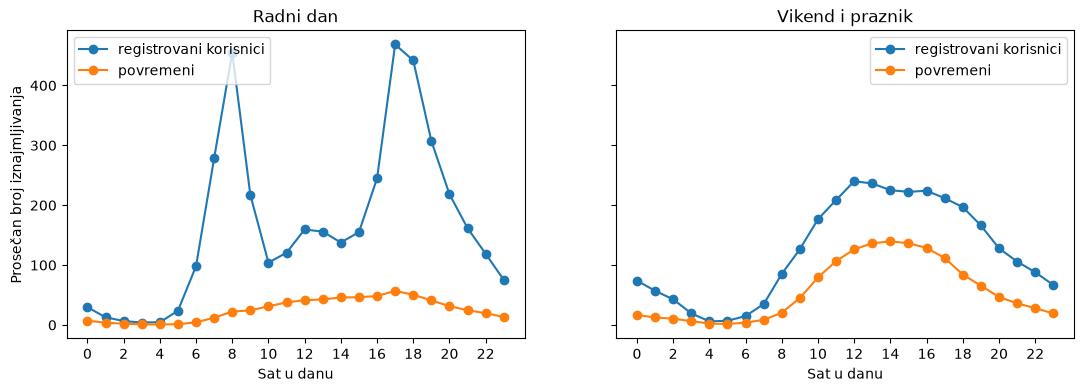

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13,4), sharey=True)

ax[0].plot(radni.index, radni["registered"], marker="o", label="registrovani korisnici")
ax[0].plot(radni.index, radni["casual"], marker="o", label="povremeni")
ax[0].set_title("Radni dan")
ax[0].set_xlabel("Sat u danu")
ax[0].set_ylabel("Prosečan broj iznajmljivanja")
ax[0].set_xticks(range(0,24,2))
ax[0].legend()

ax[1].plot(vikend.index, vikend["registered"], marker="o", label="registrovani korisnici")
ax[1].plot(vikend.index, vikend["casual"], marker="o", label="povremeni")
ax[1].set_title("Vikend i praznik")
ax[1].set_xlabel("Sat u danu")
ax[1].set_xticks(range(0,24,2))
ax[1].legend()

plt.show()

In [19]:
print("registrovani korisnici, radni dan, dva najveća sata:", list(radni["registered"].nlargest(2).index))
print("povremeni, vikend, dva najveća sata:", list(vikend["casual"].nlargest(2).index))

registrovani korisnici, radni dan, dva najveća sata: [17, 8]
povremeni, vikend, dva najveća sata: [14, 15]


Grafikon pokazuje da se dve grupe korisnika ponašaju potpuno različito.

Registrovani korisnici radnim danom imaju dva oštra vrha, u 8 i u 17 časova, što odgovara odlasku
na posao i povratku sa posla. Vikendom ta dva vrha nestaju.

Povremeni korisnici imaju jednu široku grbu oko 14 i 15 časova, i to gotovo isključivo
vikendom. Reč je o rekreativnim vožnjama.

Za modelovanje iz ovoga slede dva zaključka. Prvo, veza između sata u danu i potražnje
je izrazito nelinearna, jer se sat 8 i sat 9 razlikuju dvostruko, dok su sat 8 i sat 17
slični iako su vremenski daleko. Drugo, sat i tip dana zajedno nose informaciju koju
ne nose odvojeno, jer sat 8 radnim danom nije isto što i sat 8 vikendom.

Zbog toga očekujemo da modeli koji uče interakcije atributa, pre svega slučajne šume,
budu znatno bolji od linearnih.

## Uticaj vremenskih uslova

In [20]:
vreme = sat.groupby("weathersit")[["casual","registered"]].mean()

promena = (vreme / vreme.loc[1] - 1) * 100
promena.round(1)

,casual,registered
weathersit,,
1,0.0,0.0
2,-27.0,-11.4
3,-60.4,-41.9
4,-93.4,-56.4


In [21]:
sat["weathersit"].value_counts().sort_index()

weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

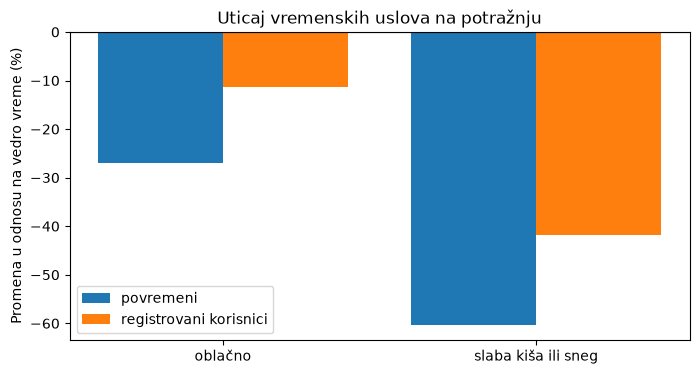

In [22]:
p = promena.loc[[2,3]]
x = np.arange(len(p))

plt.figure(figsize=(8,4))
plt.bar(x - 0.2, p["casual"], 0.4, label="povremeni")
plt.bar(x + 0.2, p["registered"], 0.4, label="registrovani korisnici")
plt.axhline(0, color="black")

plt.xticks(x, ["oblačno", "slaba kiša ili sneg"])
plt.ylabel("Promena u odnosu na vedro vreme (%)")
plt.title("Uticaj vremenskih uslova na potražnju")
plt.legend()

plt.show()

Povremeni korisnici su osetno osetljiviji na loše vreme od registrovanih korisnika. Pri oblačnom vremenu njihov broj pada za 27 odsto, a broj registrovanih korisnika za 11 odsto. Pri slaboj kiši razlika je 60 odsto naspram 42 odsto.

Objašnjenje je jednostavno. Registrovani korisnici koriste bicikl da bi stigli na posao i idu bez obzira na vreme, dok povremeni korisnici jednostavno ne izađu.

Kategorija 4, jaka kiša ili sneg, ima samo tri zapisa, pa zaključci o njoj ne bi bili pouzdani. To treba imati u vidu prilikom kodiranja atributa u svesci 02.

## Provera homoskedastičnosti

In [23]:
statistike = sat.groupby("hr")["cnt"].agg(["mean","std"])
statistike.round(1)

,mean,std
hr,,
0,53.9,42.3
1,33.4,33.5
2,22.9,26.6
3,11.7,13.2
4,6.4,4.1
5,19.9,13.2
6,76.0,55.1
7,212.1,161.4
8,359.0,235.2


In [24]:
print("odnos standardnih devijacija u 17h i u 3h:",
      round(statistike.loc[17,"std"] / statistike.loc[3,"std"], 1))

print("korelacija proseka i standardne devijacije:",
      round(statistike["mean"].corr(statistike["std"]), 3))

odnos standardnih devijacija u 17h i u 3h: 17.6
korelacija proseka i standardne devijacije: 0.973


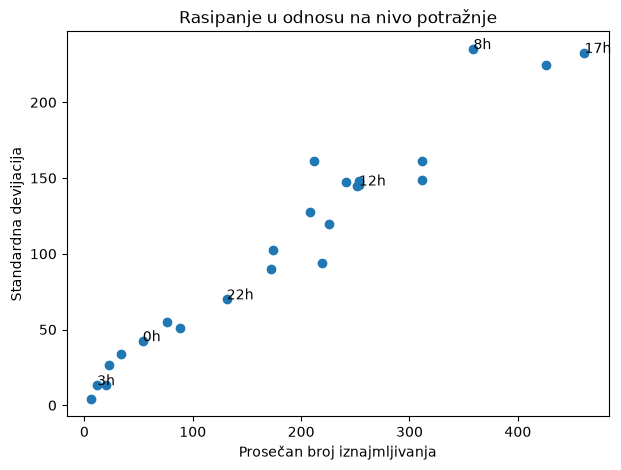

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(statistike["mean"], statistike["std"])

for h in [0, 3, 8, 12, 17, 22]:
    plt.annotate(str(h) + "h", (statistike.loc[h,"mean"], statistike.loc[h,"std"]))

plt.xlabel("Prosečan broj iznajmljivanja")
plt.ylabel("Standardna devijacija")
plt.title("Rasipanje u odnosu na nivo potražnje")

plt.show()

Korelacija između proseka i standardne devijacije po satima iznosi 0.97, a tačke na grafiku
leže gotovo na pravoj liniji. U tri ujutru sistem izda oko 12 bicikala uz rasipanje 13,
a u pet popodne oko 462 uz rasipanje 233, dakle sedamnaest puta veće.

To znači da skup podataka nije homoskedastičan. Osnovna pretpostavka linearne regresije,
da je varijansa ciljne promenljive konstantna, ovde ne važi.

Ovo je razlog zbog kojeg u svesci 03 pored obične linearne regresije radimo
i linearnu regresiju sa težinama.

## Rast sistema kroz vreme

In [26]:
po_godini = sat.groupby("yr")["cnt"].agg(["sum","mean"])
po_godini.index = ["2011", "2012"]
po_godini.round(1)

,sum,mean
2011,1243103,143.8
2012,2049576,234.7


In [27]:
print("odnos ukupnog broja iznajmljivanja 2012 prema 2011:",
      round(po_godini.loc["2012","sum"] / po_godini.loc["2011","sum"], 2))

odnos ukupnog broja iznajmljivanja 2012 prema 2011: 1.65


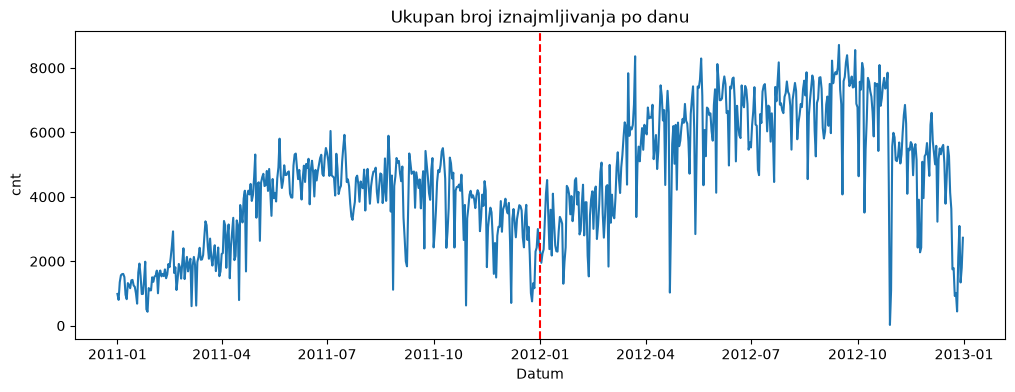

In [28]:
dan["dteday"] = pd.to_datetime(dan["dteday"])

plt.figure(figsize=(12,4))
plt.plot(dan["dteday"], dan["cnt"])
plt.axvline(pd.Timestamp("2012-01-01"), color="red", linestyle="--")

plt.title("Ukupan broj iznajmljivanja po danu")
plt.xlabel("Datum")
plt.ylabel("cnt")

plt.show()

Sistem je u 2012. godini izdao 1.65 puta više bicikala nego u 2011. Na grafiku se vidi i jasna sezonska kriva, sa vrhom leti i padom zimi, i vidljiv skok nivoa u drugoj godini.

Ovaj nalaz određuje kako ćemo deliti podatke. Nasumična podela na skup za treniranje i skup za testiranje ovde nije poštena, jer su susedni sati gotovo isti, pa bi model interpolirao između dve bliske vrednosti umesto da predviđa.

Ispravno je deliti hronološki, tako što se model uči na 2011. i testira na 2012. godini. Takva podela je teža, jer model mora da predvidi period u kojem je sistem narastao, pa će sistematski potcenjivati potražnju. To je princip koji ćemo primenjivati nadalje.

## Korelaciona analiza

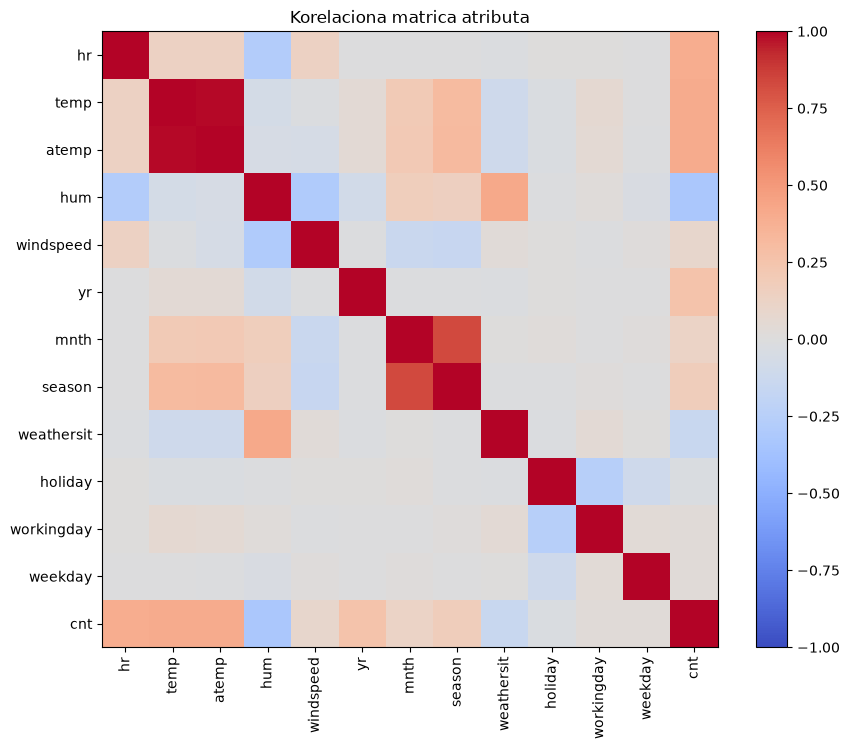

In [29]:
atributi = ["hr","temp","atemp","hum","windspeed","yr","mnth","season",
            "weathersit","holiday","workingday","weekday","cnt"]

corr = sat[atributi].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Korelaciona matrica atributa")
plt.show()

In [30]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = upper.stack().sort_values(ascending=False)
high_corr[high_corr > 0.8]

temp  atemp     0.987672
mnth  season    0.830386
dtype: float64

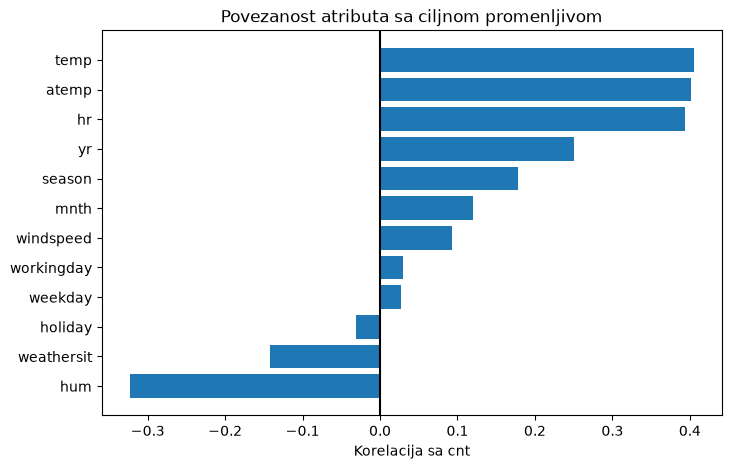

hum          -0.323
weathersit   -0.142
holiday      -0.031
weekday       0.027
workingday    0.030
windspeed     0.093
mnth          0.121
season        0.178
yr            0.250
hr            0.394
atemp         0.401
temp          0.405
Name: cnt, dtype: float64

In [31]:
kor_sa_ciljem = corr["cnt"].drop("cnt").sort_values()

plt.figure(figsize=(8,5))
plt.barh(kor_sa_ciljem.index, kor_sa_ciljem.values)
plt.axvline(0, color="black")

plt.xlabel("Korelacija sa cnt")
plt.title("Povezanost atributa sa ciljnom promenljivom")

plt.show()

kor_sa_ciljem.round(3)

Filtriranjem gornjeg trougla korelacione matrice izdvajaju se dva para atributa
sa korelacijom preko 0.8.

Atributi temp i atemp imaju korelaciju 0.99, jer oba opisuju temperaturu, samo je atemp
osećaj temperature. Zadržavanje oba unelo bi redundantnu informaciju, pa u svesci 02
zadržavamo samo temp.

Atributi mnth i season imaju korelaciju 0.83, što je očekivano jer godišnje doba
prati mesec. Njih ipak zadržavamo oba, jer mesec nosi finiju informaciju od godišnjeg doba,
a modeli zasnovani na stablima nisu osetljivi na međusobnu korelaciju atributa
onako kako su to linearni modeli.

Najjaču pozitivnu vezu sa ciljnom promenljivom imaju temperatura i sat u danu,
a najjaču negativnu vlažnost vazduha.

Vrednost korelacije za sat u danu iznosi 0.39, ali taj broj potcenjuje njegov stvarni značaj.
Korelacija meri koliko jedna promenljiva raste kada druga raste, a videli smo da potražnja
raste do 8 časova, pa opada, pa ponovo raste do 17 časova. Kod takvog oblika se porast i pad
međusobno poništavaju. Sat je verovatno najinformativniji atribut u skupu,
a linearna mera to ne prepoznaje.

Zbog toga atribute ne izbacujemo na osnovu same korelacije sa ciljnom promenljivom.

## Poređenje satnog i dnevnog nivoa

In [32]:
print("iskosenost, satni nivo: ", round(sat["cnt"].skew(), 3))
print("iskosenost, dnevni nivo:", round(dan["cnt"].skew(), 3))

iskosenost, satni nivo:  1.277
iskosenost, dnevni nivo: -0.047


Na satnom nivou raspodela je izrazito iskošena udesno, a na dnevnom je praktično simetrična. Agregacijom po danu poništava se dnevni ciklus, koji je na satnom nivou bio glavni izvor iskošenosti.

In [33]:
zajednicki = ["temp","atemp","hum","windspeed","yr","mnth",
              "season","weathersit","holiday","workingday","weekday"]

poredjenje = pd.DataFrame({
    "satni": sat[zajednicki + ["cnt"]].corr()["cnt"].drop("cnt"),
    "dnevni": dan[zajednicki + ["cnt"]].corr()["cnt"].drop("cnt")
})

poredjenje.sort_values("dnevni", key=abs, ascending=False).round(3)

,satni,dnevni
atemp,0.401,0.631
temp,0.405,0.627
yr,0.250,0.567
season,0.178,0.406
weathersit,-0.142,-0.297
mnth,0.121,0.280
windspeed,0.093,-0.235
hum,-0.323,-0.101
holiday,-0.031,-0.068
weekday,0.027,0.067


Korelacije vremenskih i sezonskih atributa sa ciljnom promenljivom su na dnevnom nivou
skoro dvostruko veće. Temperatura ide sa 0.41 na 0.63, godina sa 0.25 na 0.57,
a godišnje doba sa 0.18 na 0.41. Razlog je što se agregacijom uklanja uticaj sata u danu,
koji je na satnom nivou zaklanjao sve ostalo.

Vlažnost vazduha ide u suprotnom smeru, sa minus 0.32 na minus 0.10. Ona deluje kratkoročno,
jer kiša u datom trenutku zaustavlja vožnju, ali se tokom celog dana usrednji i izgubi.

Atribut workingday na dnevnom nivou ima korelaciju svega 0.06, iako je na satnom nivou
bio ključan za oblik krive. Objašnjenje sledi ispod.

In [34]:
dan.groupby("workingday")[["casual","registered","cnt"]].mean().round(0)

,casual,registered,cnt
workingday,,,
0,1371.0,2959.0,4330.0
1,607.0,3978.0,4585.0


Radnim danom registrovani korisnici voze više, a povremeni korisnici manje. Vikendom je obrnuto. Te dve razlike se u zbiru gotovo poništavaju, pa je ukupan broj iznajmljivanja približno isti u oba slučaja, 4585 naspram 4330.

Zbog toga tip dana na dnevnom nivou izgleda nevažno, iako na satnom nivou potpuno menja oblik krive potražnje. Signal nije nestao, nego se sakrio u razlici između dve grupe korisnika.

In [35]:
sat_std = sat.groupby("hr")["cnt"].agg(["mean","std"])
dan_std = dan.groupby("mnth")["cnt"].agg(["mean","std"])

print("korelacija proseka i standardne devijacije, satni nivo po satima:  ",
      round(sat_std["mean"].corr(sat_std["std"]), 3))
print("korelacija proseka i standardne devijacije, dnevni nivo po mesecima:",
      round(dan_std["mean"].corr(dan_std["std"]), 3))

korelacija proseka i standardne devijacije, satni nivo po satima:   0.973
korelacija proseka i standardne devijacije, dnevni nivo po mesecima: 0.259


Heteroskedastičnost je na dnevnom nivou znatno slabija, 0.26 naspram 0.97. Agregacijom se rasipanje usrednjava, pa pretpostavka o konstantnoj varijansi na dnevnom nivou nije ozbiljno narušena.

To znači da je linearna regresija sa težinama opravdana samo na satnom nivou. Na dnevnom za njom nema potrebe.

Zaključak ovog poređenja je da dnevni nivo nije isti problem u drugoj razmeri,
nego drugačiji problem. Na satnom nivou dominira dnevni ciklus, a vremenski uslovi
su sporedni. Na dnevnom nivou ciklus nestaje, pa vreme i godišnje doba postaju glavni
izvor informacije.

Zbog toga ima smisla oba nivoa modelovati odvojeno i porediti ih, kako i stoji
u naslovu projekta.

# Zaključci

1. Skup podataka nema nedostajućih vrednosti, ali nedostaje 165 sati kao redova,
   uglavnom u noćnim satima. Praznine ne popunjavamo jer ne predviđamo iz prethodnih vrednosti.

2. Kolona cnt je tačan zbir kolona casual i registered. Ta dva atributa moraju biti
   izbačena iz ulaznih atributa da ne bi došlo do curenja informacija.

3. Povremeni korisnici i registrovani korisnici čine dve različite populacije, sa različitim satnim
   obrascima i dvostruko različitom osetljivošću na vremenske uslove.

4. Veza između sata u danu i potražnje je izrazito nelinearna i sadrži interakciju
   sa tipom dana. Očekujemo da modeli zasnovani na stablima nadmaše linearne.

5. Skup podataka nije homoskedastičan, jer rasipanje raste sa nivoom potražnje.
   Korelacija proseka i standardne devijacije po satima iznosi 0.97.

6. Sistem je između 2011. i 2012. godine narastao 1.65 puta, zbog čega podela
   na skup za treniranje i skup za testiranje mora biti hronološka.

7. Atributi temp i atemp su gotovo identični, pa zadržavamo samo jedan.

